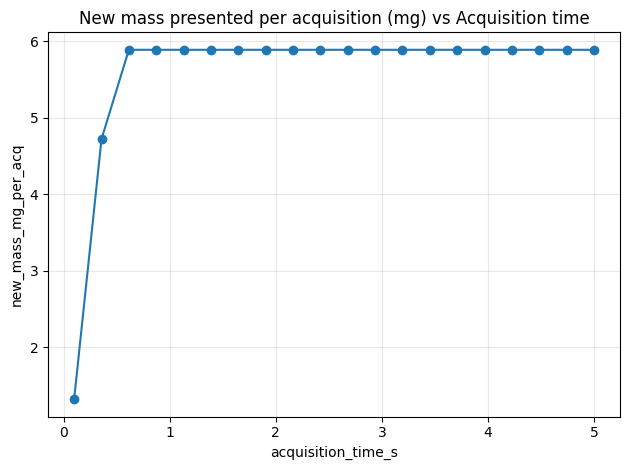

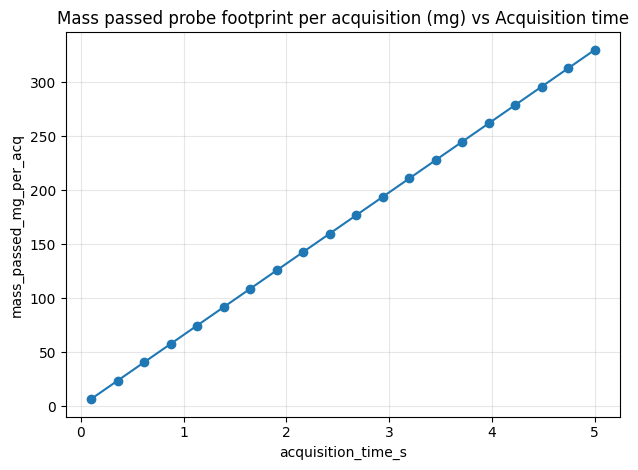

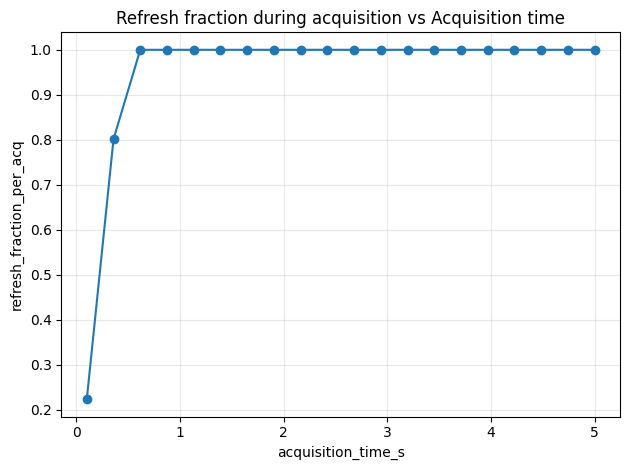

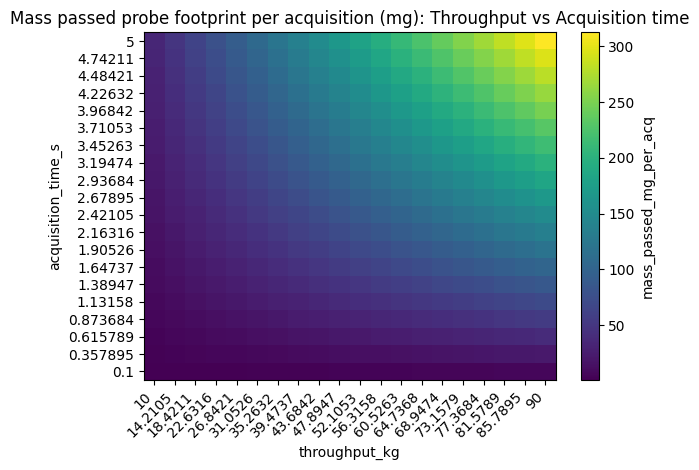

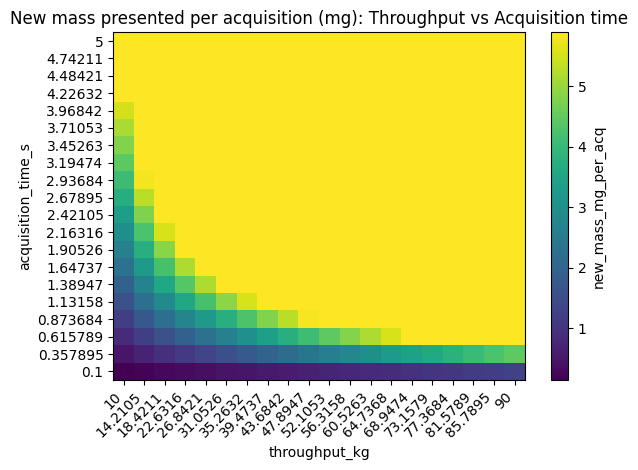


Baseline scenario metrics:
  velocity_mm_s: 11.1998
  probe_mass_mg_instant: 5.89049
  acquisition_time_s: 1
  new_mass_mg_per_acq: 5.89049
  mass_passed_mg_per_acq: 65.9722
  refresh_fraction_per_acq: 1

Saved CSV + figures in: /home/ersk/outputs


In [13]:
"""
Powder plug-flow + NIR probe sampling simulator (adds: mass passed probe footprint)
=================================================================================

Adds an explicit "mass passed the probe footprint during acquisition" metric:

    m_pass(T) = rho * A_window * v * T

This is the mass of powder that would cross an imagined plane coincident with the
probe window area during the acquisition time T (plug-flow assumption).

Important distinctions
----------------------
1) Instantaneous probed mass (mg):      m_inst = rho * A_window * depth
   - mass "in view" at any instant.

2) New mass presented per acquisition (mg): 
      m_new = m_inst * min(1, (v*T)/L_axial)
   - a refresh-based proxy for how much *unique* material contributes to a spectrum.
   - plateaus at m_inst.

3) Mass passed probe footprint (mg):
      m_pass = rho * A_window * v * T
   - grows linearly with acquisition time and is not bounded by m_inst.
   - useful for transport/throughput-style arguments; do NOT confuse with (2).

Outputs: plots + CSVs saved in ./outputs/
"""

from __future__ import annotations

import os
import math
from dataclasses import dataclass
from typing import Iterable, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------- Configuration -----------------------------

@dataclass(frozen=True)
class BaseParams:
    # Geometry
    pipe_diameter_cm: float = 10.0
    probe_window_diameter_cm: float = 0.5
    measurement_depth_cm: float = 0.1  # 1 mm = 0.1 cm

    # Material
    bulk_density_g_per_cm3: float = 0.3

    # Throughput (mass flow)
    throughput_kg: float = 1.0
    throughput_time_s: float = 5.0 * 60.0  # 5 minutes

    # If set, overrides velocity derived from throughput (units: cm/s)
    velocity_override_cm_s: Optional[float] = None

    # Spectral acquisition time (seconds)
    acquisition_time_s: float = 1.0

    # Refresh model: axial sampling length proxy
    # "window_diameter" or "custom"
    axial_length_model: str = "window_diameter"
    axial_length_custom_cm: float = 0.5  # used if axial_length_model == "custom"


def ensure_output_dir(path: str = "outputs") -> str:
    os.makedirs(path, exist_ok=True)
    return path


# ----------------------------- Core physics -----------------------------

def area_circle_cm2(d_cm: float) -> float:
    r = d_cm / 2.0
    return math.pi * r * r


def throughput_to_velocity_cm_s(
    pipe_diameter_cm: float,
    bulk_density_g_per_cm3: float,
    throughput_kg: float,
    throughput_time_s: float,
) -> float:
    if pipe_diameter_cm <= 0:
        raise ValueError("pipe_diameter_cm must be > 0")
    if bulk_density_g_per_cm3 <= 0:
        raise ValueError("bulk_density_g_per_cm3 must be > 0")
    if throughput_kg < 0:
        raise ValueError("throughput_kg must be >= 0")
    if throughput_time_s <= 0:
        raise ValueError("throughput_time_s must be > 0")

    mdot_g_s = (throughput_kg * 1000.0) / throughput_time_s  # kg -> g/s
    vdot_cm3_s = mdot_g_s / bulk_density_g_per_cm3
    A_pipe_cm2 = area_circle_cm2(pipe_diameter_cm)
    return vdot_cm3_s / A_pipe_cm2


def axial_sampling_length_cm(params: BaseParams) -> float:
    if params.axial_length_model == "window_diameter":
        return params.probe_window_diameter_cm
    if params.axial_length_model == "custom":
        if params.axial_length_custom_cm <= 0:
            raise ValueError("axial_length_custom_cm must be > 0 when using custom model")
        return params.axial_length_custom_cm
    raise ValueError("axial_length_model must be 'window_diameter' or 'custom'")


def compute_metrics(params: BaseParams) -> Dict[str, float]:
    A_pipe_cm2 = area_circle_cm2(params.pipe_diameter_cm)
    A_win_cm2 = area_circle_cm2(params.probe_window_diameter_cm)

    # velocity (cm/s)
    if params.velocity_override_cm_s is None:
        v_cm_s = throughput_to_velocity_cm_s(
            pipe_diameter_cm=params.pipe_diameter_cm,
            bulk_density_g_per_cm3=params.bulk_density_g_per_cm3,
            throughput_kg=params.throughput_kg,
            throughput_time_s=params.throughput_time_s,
        )
        velocity_source = "derived_from_throughput"
    else:
        if params.velocity_override_cm_s < 0:
            raise ValueError("velocity_override_cm_s must be >= 0")
        v_cm_s = params.velocity_override_cm_s
        velocity_source = "user_override"

    if params.acquisition_time_s <= 0:
        raise ValueError("acquisition_time_s must be > 0")

    # instantaneous sampled mass (mass "in view")
    V_probe_cm3 = A_win_cm2 * params.measurement_depth_cm
    m_inst_g = V_probe_cm3 * params.bulk_density_g_per_cm3

    # refresh / "new mass presented" over acquisition time
    L_ax_cm = axial_sampling_length_cm(params)
    dz_cm = v_cm_s * params.acquisition_time_s
    f_refresh = 0.0 if L_ax_cm == 0 else min(1.0, dz_cm / L_ax_cm)
    m_new_g_per_acq = f_refresh * m_inst_g

    # mass passed the probe footprint during acquisition time
    # m_pass = rho * A_window * v * T
    m_pass_g_per_acq = params.bulk_density_g_per_cm3 * A_win_cm2 * v_cm_s * params.acquisition_time_s

    # optional exposure proxy (mass-time)
    m_time_g_s = m_inst_g * params.acquisition_time_s

    # derived flows for reporting
    mdot_g_s = (params.throughput_kg * 1000.0) / params.throughput_time_s
    vdot_cm3_s = mdot_g_s / params.bulk_density_g_per_cm3

    return {
        "pipe_diameter_cm": params.pipe_diameter_cm,
        "pipe_area_cm2": A_pipe_cm2,
        "probe_window_diameter_cm": params.probe_window_diameter_cm,
        "probe_window_area_cm2": A_win_cm2,
        "measurement_depth_cm": params.measurement_depth_cm,
        "bulk_density_g_per_cm3": params.bulk_density_g_per_cm3,
        "throughput_kg": params.throughput_kg,
        "throughput_time_s": params.throughput_time_s,
        "mass_flow_g_s": mdot_g_s,
        "vol_flow_cm3_s": vdot_cm3_s,
        "velocity_source": velocity_source,
        "velocity_cm_s": v_cm_s,
        "velocity_mm_s": v_cm_s * 10.0,
        "acquisition_time_s": params.acquisition_time_s,
        "axial_length_model": params.axial_length_model,
        "axial_sampling_length_cm": L_ax_cm,
        "advance_dz_cm_per_acq": dz_cm,
        "refresh_fraction_per_acq": f_refresh,
        "probe_volume_cm3": V_probe_cm3,
        "probe_mass_g_instant": m_inst_g,
        "probe_mass_mg_instant": m_inst_g * 1000.0,
        "new_mass_g_per_acq": m_new_g_per_acq,
        "new_mass_mg_per_acq": m_new_g_per_acq * 1000.0,
        "mass_passed_g_per_acq": m_pass_g_per_acq,
        "mass_passed_mg_per_acq": m_pass_g_per_acq * 1000.0,
        "mass_time_exposure_g_s": m_time_g_s,
        "mass_time_exposure_mg_s": m_time_g_s * 1000.0,
    }


# ----------------------------- Sweeps -----------------------------

def linspace_list(start: float, stop: float, n: int) -> List[float]:
    if n < 2:
        return [float(start)]
    return list(np.linspace(start, stop, n))


def run_sweep(base: BaseParams, sweep: Dict[str, Iterable[float]]) -> pd.DataFrame:
    base_fields = set(base.__dataclass_fields__.keys())
    for k in sweep.keys():
        if k not in base_fields:
            raise KeyError(f"Unknown BaseParams field in sweep: '{k}'")

    keys = list(sweep.keys())
    values = [list(sweep[k]) for k in keys]
    grids = np.meshgrid(*values, indexing="ij")
    combos = np.stack([g.ravel() for g in grids], axis=1)

    rows: List[Dict[str, float]] = []
    for combo in combos:
        kwargs = {k: float(v) for k, v in zip(keys, combo)}
        p = BaseParams(**{**base.__dict__, **kwargs})
        rows.append(compute_metrics(p))

    return pd.DataFrame(rows)


# ----------------------------- Plotting -----------------------------

def plot_sensitivity_1d(df: pd.DataFrame, x: str, y: str, title: str, outpath: Optional[str] = None) -> None:
    df_sorted = df.sort_values(x)
    plt.figure()
    plt.plot(df_sorted[x].to_numpy(), df_sorted[y].to_numpy(), marker="o")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if outpath:
        plt.tight_layout()
        plt.savefig(outpath, dpi=200)
    plt.show()


def plot_heatmap(df: pd.DataFrame, x: str, y: str, z: str, title: str, outpath: Optional[str] = None) -> None:
    pivot = df.pivot_table(index=y, columns=x, values=z, aggfunc="mean")
    plt.figure()
    plt.imshow(pivot.to_numpy(), aspect="auto", origin="lower")
    plt.xticks(
        ticks=np.arange(pivot.shape[1]),
        labels=[f"{v:g}" for v in pivot.columns],
        rotation=45,
        ha="right",
    )
    plt.yticks(ticks=np.arange(pivot.shape[0]), labels=[f"{v:g}" for v in pivot.index])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    cbar = plt.colorbar()
    cbar.set_label(z)
    if outpath:
        plt.tight_layout()
        plt.savefig(outpath, dpi=200)
    plt.show()


# ----------------------------- Main -----------------------------

def main() -> None:
    outdir = ensure_output_dir("outputs")

    # Base scenario (edit freely)
    base = BaseParams(
        pipe_diameter_cm=10.0,
        probe_window_diameter_cm=0.5,
        measurement_depth_cm=0.1,      # 1 mm
        bulk_density_g_per_cm3=0.3,
        throughput_kg=95.0,
        throughput_time_s=60 * 60.0,    # 5 minutes
        velocity_override_cm_s=None,   # set to a number to override velocity
        acquisition_time_s=1.0,
        axial_length_model="window_diameter",  # or "custom"
        axial_length_custom_cm=0.5,
    )

    # --------- Sweeps ---------
    sweep_acq = {"acquisition_time_s": linspace_list(0.1, 5.0, 20)}  # 100 ms to 5 s

    # 2D sweep example: acquisition time vs throughput
    sweep_2d = {
        "throughput_kg": linspace_list(10, 90, 20),
        "acquisition_time_s": linspace_list(0.1, 5.0, 20),
    }

    df_acq = run_sweep(base, sweep_acq)
    df_2d = run_sweep(base, sweep_2d)

    # Save
    df_acq.to_csv(os.path.join(outdir, "sweep_acquisition_time.csv"), index=False)
    df_2d.to_csv(os.path.join(outdir, "sweep_2d_throughput_vs_acquisition.csv"), index=False)

    # --------- Plots: acquisition time effects ---------
    plot_sensitivity_1d(
        df_acq, "acquisition_time_s", "new_mass_mg_per_acq",
        "New mass presented per acquisition (mg) vs Acquisition time",
        outpath=os.path.join(outdir, "new_mass_per_acq_vs_acquisition_time.png"),
    )
    plot_sensitivity_1d(
        df_acq, "acquisition_time_s", "mass_passed_mg_per_acq",
        "Mass passed probe footprint per acquisition (mg) vs Acquisition time",
        outpath=os.path.join(outdir, "mass_passed_vs_acquisition_time.png"),
    )
    plot_sensitivity_1d(
        df_acq, "acquisition_time_s", "refresh_fraction_per_acq",
        "Refresh fraction during acquisition vs Acquisition time",
        outpath=os.path.join(outdir, "refresh_fraction_vs_acquisition_time.png"),
    )

    # --------- Heatmap: throughput vs acquisition time (mass passed) ---------
    plot_heatmap(
        df_2d,
        x="throughput_kg",
        y="acquisition_time_s",
        z="mass_passed_mg_per_acq",
        title="Mass passed probe footprint per acquisition (mg): Throughput vs Acquisition time",
        outpath=os.path.join(outdir, "heatmap_mass_passed_throughput_vs_acquisition.png"),
    )
    plot_heatmap(
        df_2d,
        x="throughput_kg",
        y="acquisition_time_s",
        z="new_mass_mg_per_acq",
        title="New mass presented per acquisition (mg): Throughput vs Acquisition time",
        outpath=os.path.join(outdir, "heatmap_new_mass_throughput_vs_acquisition.png"),
    )

    # Baseline summary
    base_metrics = compute_metrics(base)
    print("\nBaseline scenario metrics:")
    for k in [
        "velocity_mm_s",
        "probe_mass_mg_instant",
        "acquisition_time_s",
        "new_mass_mg_per_acq",
        "mass_passed_mg_per_acq",
        "refresh_fraction_per_acq",
    ]:
        v = base_metrics[k]
        if isinstance(v, (int, float)):
            print(f"  {k}: {v:.6g}")
        else:
            print(f"  {k}: {v}")

    print(f"\nSaved CSV + figures in: {os.path.abspath(outdir)}")


if __name__ == "__main__":
    main()
